# CS336 Assignment 1 — training experiments

A TransformerLM trained on TinyStories (4 layers, d_model=512, 16 heads, d_ff=1344, context 256, vocab 10k, ~17M non-embedding params), using my own AdamW with cosine LR, warmup 200, weight decay 0.1, and grad clip 1.0.

Run data comes from wandb (`jerzhou-personal-team/cs336-assignment-1`). The notebook covers:

1. **Learning-rate sweep.** The best LR is fairly broad, from 3e-3 to 1e-2. At 3e-2, training stalls; this is past the edge of stability.
2. **Batch-size sweep.** Measured per *step*, bigger batches are better. Measured per *token*, the curves mostly collapse. At a fixed budget of 328M tokens, batch sizes 64, 128, and 256 reach the same loss.
3. **Architecture ablations.** These cover removing RMSNorm, post-norm, NoPE, SiLU instead of SwiGLU, and no weight decay. Removing RMSNorm is the only change that really hurts, and it makes training blow up at the baseline LR.

All curves are **validation loss** unless labelled otherwise. Validation loss is averaged over 50 random batches every 250 steps.

In [1]:
import functools
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import wandb

PROJECT = "jerzhou-personal-team/cs336-assignment-1"
CONTEXT_LENGTH = 256
FIG_DIR = Path("figures")  # PNGs used by the README
FIG_DIR.mkdir(exist_ok=True)
api = wandb.Api()

# --- plot style: recessive axes, thin lines, ink-colored text ---
INK, INK_2, MUTED, GRID = "#0b0b0b", "#52514e", "#8a8984", "#e6e5e1"
# Categorical palette (validated for color-vision deficiency in this fixed order).
# Used for sweep values: the legends are ordered, but adjacent curves need distinct hues.
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
ACCENT = "#2a78d6"   # the variant in ablation panels
BASE = "#a3a29c"     # the baseline in ablation panels

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": MUTED,
    "axes.labelcolor": INK_2,
    "axes.titlecolor": INK,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "xtick.color": INK_2,
    "ytick.color": INK_2,
    "lines.linewidth": 1.8,
    "legend.frameon": False,
    "legend.fontsize": 9,
    "font.size": 10,
})

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


## Which runs are used

The wandb project has 26 runs. The ones below were chosen deliberately. Any run that is cut short is drawn **dashed** and ends in an **×**.

Several runs marked `failed` in wandb actually trained correctly. The crash came when `torch.save` hit **"No space left on device"** while writing a checkpoint, so their curves are valid up to that point. Where a full-length rerun exists, the rerun is used.

In [2]:
# run id -> short label. Grouped by experiment; every run here uses commit 2a31011 / c58db3f (identical model code)
# unless it is an ablation, which lives on its own branch.
LR_SWEEP = {  # batch 128, 10k steps
    "ahgsuo0e": 1e-4,   # earnest-sweep-3   (disk full at step 1000)
    "2g1g00vx": 3e-4,   # leafy-cloud-4
    "twk5tmaq": 1e-3,   # different-wood-13 (rerun of helpful-sweep-2, which hit disk-full at 7000)
    "ie2vyove": 3e-3,   # summer-sweep-1
    "ug9tshkx": 1e-2,   # absurd-totem-3
    "1cm7uruf": 3e-2,   # lively-terrain-5  (killed at step 2930 - stalled)
}
BS_SWEEP = {  # lr 3e-3, 10k steps (except bs 256)
    "8ni155ij": 1,      # avid-sweep-1
    "xm9ja9j1": 16,     # vocal-sweep-2
    "owycaj86": 64,     # crimson-wind-12   (rerun of wobbly-sweep-3, disk-full at 6000)
    "ie2vyove": 128,    # summer-sweep-1
    "r3ub5u9d": 256,    # ethereal-plant-14 (5k steps; lucky-sweep-4 at 10k hit disk-full at step 1000)
}
BS64_20K = "bjg043mu"   # upbeat-eon-15: bs 64 for 20k steps -> same token count as bs 128 x 10k

BASELINE = "ie2vyove"   # lr 3e-3, bs 128 - also the best 10k-step run
BASELINE_RERUN = "i1rhqk7o"  # peach-yogurt-17: same config at c58db3f, killed at 2720 - reproducibility check
ABLATIONS = {  # all lr 3e-3, bs 128, 10k steps
    "6mni5hk2": "Post-norm",                       # devoted-lion-20   (branch ablation-post-norm)
    "zo74utvk": "NoPE (no RoPE)",                  # confused-surf-21  (ablation-nope; disk-full *after* step 10000)
    "h4kj3vat": "SiLU FFN (d_ff=2048, param-matched)",  # quiet-oath-22 (ablation-silu)
    "dt5rauvz": "Weight decay 0",                  # fanciful-energy-18
}
NO_NORM_HI_LR = "srx06bxn"   # stilted-sponge-19: no RMSNorm, lr 3e-3
NO_NORM_LO_LR = "913cbb89"   # giddy-donkey-23:   no RMSNorm, lr 3e-4 (killed at 6380)
BASELINE_LO_LR = "2g1g00vx"  # leafy-cloud-4: baseline at lr 3e-4

EXCLUDED = {
    "charmed-night-1":  "crashed at step 0 (get_batch device bug)",
    "confused-totem-2": "crashed at step 0 (RoPE shape bug, before 'fix RoPE bug')",
    "snowy-sun-4":      "crashed at step 0 (same RoPE bug, stale code on 2nd machine)",
    "feasible-fire-3":  "early smoke test (lr 3e-4, bs 64, 5k steps), not part of a sweep",
    "helpful-sweep-2":  "disk-full at 7000; superseded by different-wood-13",
    "wobbly-sweep-3":   "disk-full at 6000; superseded by crimson-wind-12",
    "lucky-sweep-4":    "disk-full at 1000; superseded by ethereal-plant-14",
    "glad-salad-11":    "tried to resume wobbly-sweep-3 from a corrupted checkpoint",
    "helpful-water-16": "accidentally launched on CPU, killed with no logged steps",
}
pd.DataFrame(EXCLUDED.items(), columns=["excluded run", "reason"]).style.hide(axis="index")

excluded run,reason
charmed-night-1,crashed at step 0 (get_batch device bug)
confused-totem-2,"crashed at step 0 (RoPE shape bug, before 'fix RoPE bug')"
snowy-sun-4,"crashed at step 0 (same RoPE bug, stale code on 2nd machine)"
feasible-fire-3,"early smoke test (lr 3e-4, bs 64, 5k steps), not part of a sweep"
helpful-sweep-2,disk-full at 7000; superseded by different-wood-13
wobbly-sweep-3,disk-full at 6000; superseded by crimson-wind-12
lucky-sweep-4,disk-full at 1000; superseded by ethereal-plant-14
glad-salad-11,tried to resume wobbly-sweep-3 from a corrupted checkpoint
helpful-water-16,"accidentally launched on CPU, killed with no logged steps"


In [3]:
@dataclass
class Run:
    id: str
    name: str
    state: str
    config: dict
    runtime_s: float
    train: pd.DataFrame  # index: step; columns: train/loss, lr
    val: pd.Series       # index: step

    @property
    def last_step(self) -> int:
        return int(self.train.index.max())

    @property
    def complete(self) -> bool:
        return self.last_step >= self.config["total_iters"]

    @property
    def tokens_per_step(self) -> int:
        return self.config["batch_size"] * CONTEXT_LENGTH


@functools.cache
def load(run_id: str) -> Run:
    r = api.run(f"{PROJECT}/{run_id}")
    train = r.history(keys=["train/loss", "lr"], samples=100_000).set_index("_step").sort_index()
    val = r.history(keys=["val/loss"], samples=100_000).set_index("_step")["val/loss"].sort_index()
    return Run(run_id, r.name, r.state, dict(r.config), r.summary.get("_runtime", np.nan), train, val)


def plot_curve(ax, x, y, run: Run, color, label, **kw):
    # Solid if the run completed, dashed + "x" at the last point if it was cut short.
    ls = "-" if run.complete else "--"
    ax.plot(x, y, color=color, ls=ls, label=label, **kw)
    if not run.complete:
        ax.plot(x[-1], y[-1], marker="x", ms=8, mew=2, color=color, ls="none")


def ema(s: pd.Series, alpha=0.1) -> pd.Series:
    return s.ewm(alpha=alpha).mean()


all_ids = {*LR_SWEEP, *BS_SWEEP, BS64_20K, BASELINE, BASELINE_RERUN, *ABLATIONS, NO_NORM_HI_LR, NO_NORM_LO_LR}
runs = {rid: load(rid) for rid in all_ids}
pd.DataFrame([
    dict(run=r.name, lr=r.config["lr"], batch=r.config["batch_size"], steps=f"{r.last_step}/{r.config['total_iters']}",
         wd=r.config["weight_decay"], final_val=round(r.val.iloc[-1], 3), wandb_state=r.state)
    for r in sorted(runs.values(), key=lambda r: r.name)
]).style.hide(axis="index")

run,lr,batch,steps,wd,final_val,wandb_state
absurd-totem-3,0.010000,128,10000/10000,0.100000,1.330000,finished
avid-sweep-1,0.003000,1,10000/10000,0.100000,2.942000,finished
confused-surf-21,0.003000,128,10000/10000,0.100000,1.390000,failed
crimson-wind-12,0.003000,64,10000/10000,0.100000,1.414000,finished
devoted-lion-20,0.003000,128,10000/10000,0.100000,1.359000,finished
different-wood-13,0.001000,128,10000/10000,0.100000,1.381000,finished
earnest-sweep-3,0.000100,128,1000/10000,0.100000,2.595000,failed
ethereal-plant-14,0.003000,256,5000/5000,0.100000,1.340000,finished
fanciful-energy-18,0.003000,128,10000/10000,0.000000,1.359000,finished
giddy-donkey-23,0.000300,128,6380/10000,0.100000,1.615000,killed


In [4]:
# Sanity check: how much do two runs with the same config differ? This sets the noise floor for the comparisons below.
a, b = runs[BASELINE].val, runs[BASELINE_RERUN].val
common = a.index.intersection(b.index)
diff = (a[common] - b[common]).abs()
print(f"{runs[BASELINE].name} vs {runs[BASELINE_RERUN].name} (same config and seed, different machine), "
      f"{len(common)} shared evals up to step {common.max()}:")
print(f"  mean |delta val loss| = {diff.mean():.4f}, max = {diff.max():.4f}")

summer-sweep-1 vs peach-yogurt-17 (same config and seed, different machine), 10 shared evals up to step 2500:
  mean |delta val loss| = 0.0068, max = 0.0182


Gaps of roughly **0.01–0.02** in validation loss are within run-to-run noise. Keep that in mind when comparing runs whose final losses are close.

## 1. Learning-rate sweep

Batch size 128 and 10k steps (about 328M tokens). The cosine schedule decays to `lr_min = 3e-5` in every run, so only the peak LR changes.

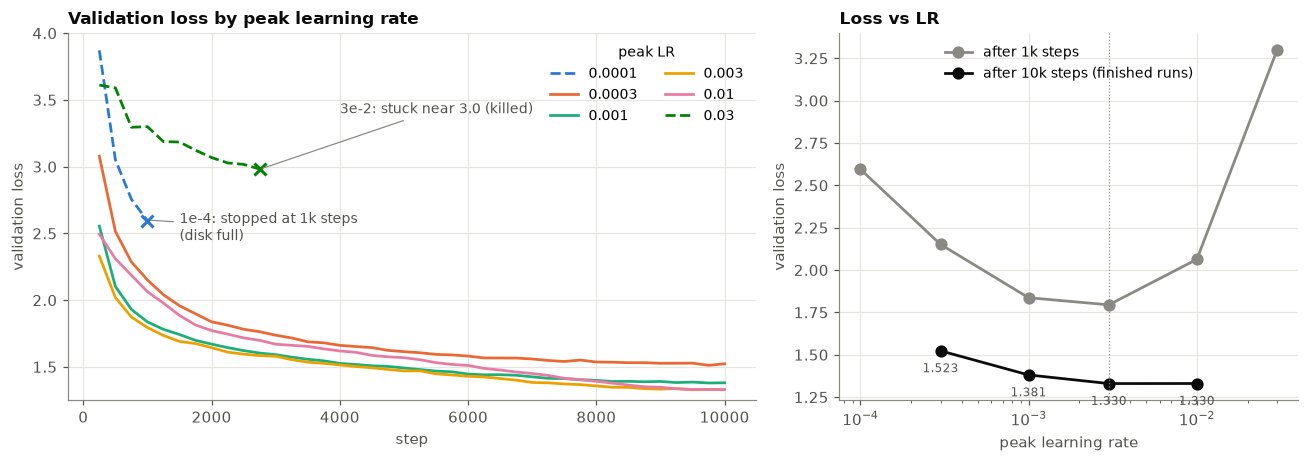

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.3), gridspec_kw={"width_ratios": [1.5, 1]})

LR_COLOR = dict(zip(LR_SWEEP.values(), PALETTE))
for rid, lr in LR_SWEEP.items():
    r = runs[rid]
    color = LR_COLOR[lr]
    plot_curve(ax1, r.val.index.values, r.val.values, r, color, f"{lr:g}")
ax1.set(xlabel="step", ylabel="validation loss", ylim=(1.25, 4.0), title="Validation loss by peak learning rate")
ax1.legend(title="peak LR", title_fontsize=9, ncol=2)
ax1.annotate("3e-2: stuck near 3.0 (killed)", xy=(2750, 2.98), xytext=(4000, 3.4), color=INK_2, fontsize=9,
             arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.8))
ax1.annotate("1e-4: stopped at 1k steps\n(disk full)", xy=(1000, 2.60), xytext=(1500, 2.45), color=INK_2, fontsize=9,
             arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.8))

# Every run in the sweep reached step 1000, so that gives a clean comparison across all six LRs.
lrs = np.array(list(LR_SWEEP.values()))
at_1k = [runs[rid].val.get(1000) for rid in LR_SWEEP]
at_end = [runs[rid].val.get(10000, np.nan) for rid in LR_SWEEP]
ax2.plot(lrs, at_1k, "o-", color=MUTED, ms=7, label="after 1k steps")
ax2.plot(lrs, at_end, "o-", color=INK, ms=7, label="after 10k steps (finished runs)")
ax2.set_xscale("log")
ax2.set(xlabel="peak learning rate", ylabel="validation loss", title="Loss vs LR")
best = lrs[np.nanargmin(at_end)]
ax2.axvline(best, color=MUTED, lw=0.8, ls=":")
for lr, v in zip(lrs, at_end):
    if not np.isnan(v):
        ax2.annotate(f"{v:.3f}", (lr, v), textcoords="offset points", xytext=(0, -14), ha="center", fontsize=8, color=INK_2)
ax2.legend(loc="upper center")
fig.tight_layout()
fig.savefig(FIG_DIR / "lr_sweep.png", dpi=150, bbox_inches="tight")

**What this shows**

- The final losses form a U-shape with a wide, flat bottom. Peak LRs of 3e-3 and 1e-2 finish at the same loss (1.330), well inside run-to-run noise. Because the cosine decay lets the high-LR run settle at the end, the final loss barely tells them apart. The 1k-step snapshot does: the optimum then sits clearly at 1e-3 to 3e-3, and 1e-2 is already noticeably worse.
- At 3e-2 the run is **past the edge of stability**. The training-loss plot below shows the failure clearly. The loss falls normally during warmup, but as the LR reaches its peak at step 200, the loss turns *upward*, from about 3.45 to about 3.75. After that it only creeps down, and it is still near 3.0 when the run was killed at step 2.9k, while every other run is below 1.8. It never diverges to NaN; grad clipping at 1.0 probably prevents that.
- Small LRs are simply slow. After 10k steps, 3e-4 is still 0.19 nats behind 3e-3.

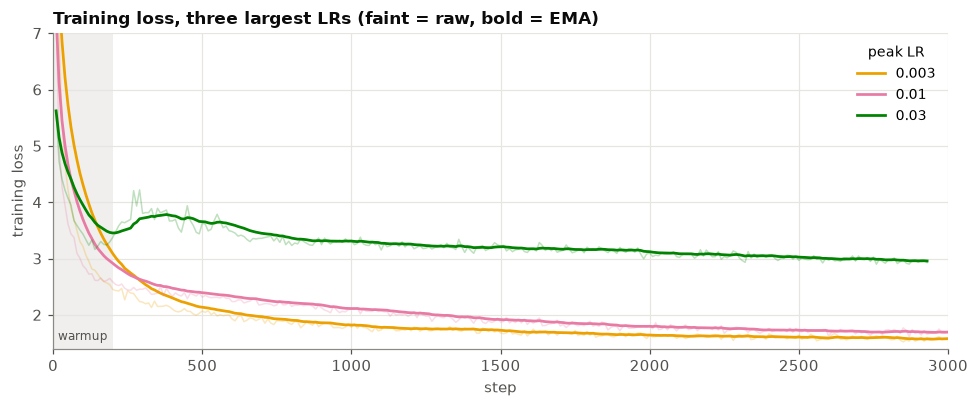

In [6]:
fig, ax = plt.subplots(figsize=(9, 3.8))
for rid, lr in LR_SWEEP.items():
    if lr < 3e-3:
        continue
    r, color = runs[rid], LR_COLOR[lr]
    t = r.train.loc[:3000, "train/loss"]
    ax.plot(t.index, t.values, color=color, alpha=0.25, lw=1)
    ax.plot(t.index, ema(t).values, color=color, label=f"{lr:g}")
ax.set(xlabel="step", ylabel="training loss", ylim=(1.4, 7), xlim=(0, 3000),
       title="Training loss, three largest LRs (faint = raw, bold = EMA)")
ax.axvspan(0, 200, color=GRID, alpha=0.6, lw=0)
ax.text(100, 1.5, "warmup", ha="center", va="bottom", fontsize=8, color=INK_2)
ax.legend(title="peak LR", title_fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "lr_train_loss.png", dpi=150, bbox_inches="tight")

## 2. Batch-size sweep

Peak LR is fixed at 3e-3 for every batch size; the LR was not re-tuned per batch size. The left panel plots loss against **optimizer steps** and the right panel against **tokens seen** (batch × 256 × step).

The bs = 256 run uses a 5k-step schedule. The 10k-step attempt (`lucky-sweep-4`) died at step 1000 when the disk filled, so this run sees the same total tokens as bs = 128 × 10k.

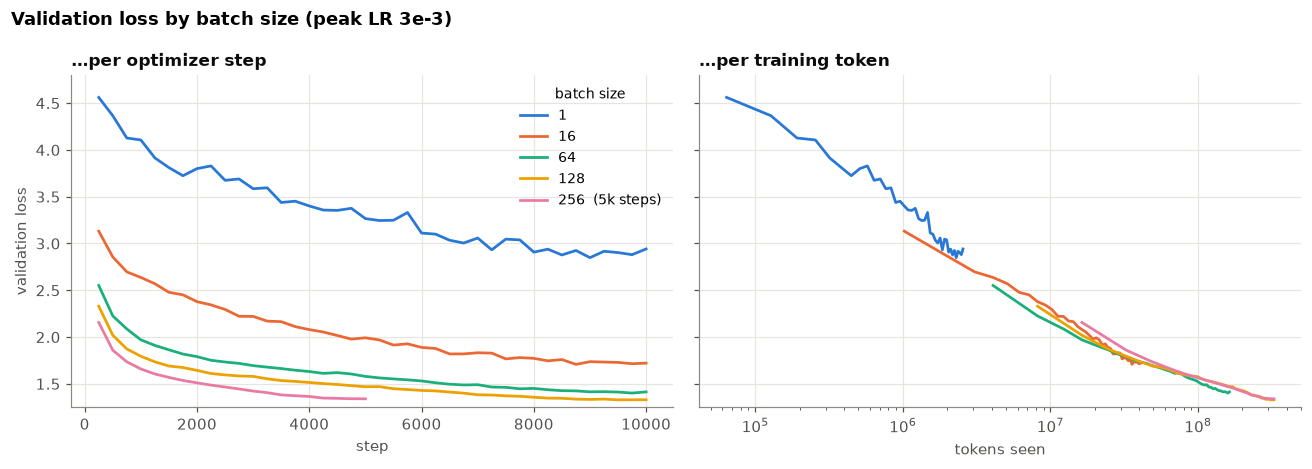

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.3), sharey=True)
BS_COLOR = dict(zip(BS_SWEEP.values(), PALETTE))
for rid, bs in BS_SWEEP.items():
    r, color = runs[rid], BS_COLOR[bs]
    steps = r.val.index.values
    label = f"{bs}" + (f"  ({r.config['total_iters'] // 1000}k steps)" if r.config["total_iters"] != 10000 else "")
    plot_curve(ax1, steps, r.val.values, r, color, label)
    plot_curve(ax2, steps * r.tokens_per_step, r.val.values, r, color, label)
ax1.set(xlabel="step", ylabel="validation loss", ylim=(1.25, 4.8), title="…per optimizer step")
ax2.set(xlabel="tokens seen", xscale="log", title="…per training token")
ax1.legend(title="batch size", title_fontsize=9)
fig.suptitle("Validation loss by batch size (peak LR 3e-3)", x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "batch_size_sweep.png", dpi=150, bbox_inches="tight")

**What this shows**

- **Per step**, larger batches always win. Each step averages the gradient over more data, so the gradient noise is lower.
- **Per token**, the curves nearly collapse for batch sizes from 16 to 256. bs 64 is marginally the most token-efficient, and bs 16 and bs 256 sit slightly above it, but the spread is small. Over this range, a token is worth about the same however it is batched, and a larger batch mostly buys fewer, more parallel steps. That is the regime below the critical batch size.
- bs = 1 breaks the pattern and lies *above* the shared curve. The likely reason is that one 256-token sequence gives a gradient so noisy that a peak LR tuned for bs = 128 is too aggressive. This sweep doesn't test that directly, because the LR wasn't re-tuned for bs = 1.
- The bs = 1 curve also looks noisy because validation draws the **same batch size as training** (`get_batch(val, args.batch_size, …)`). Its loss estimate therefore averages only 50 × 256 tokens.

### Fixed token budget: bs 64 × 20k steps vs. bs 128 × 10k vs. bs 256 × 5k

Each of these three runs saw 328M tokens and used a cosine schedule matched to its own length.

run,batch,steps,tokens,final_val,min_val,wall_clock_min
upbeat-eon-15,64,20000,328M,1.338000,1.324000,59
summer-sweep-1,128,10000,328M,1.330000,1.329000,63
ethereal-plant-14,256,5000,328M,1.340000,1.340000,55


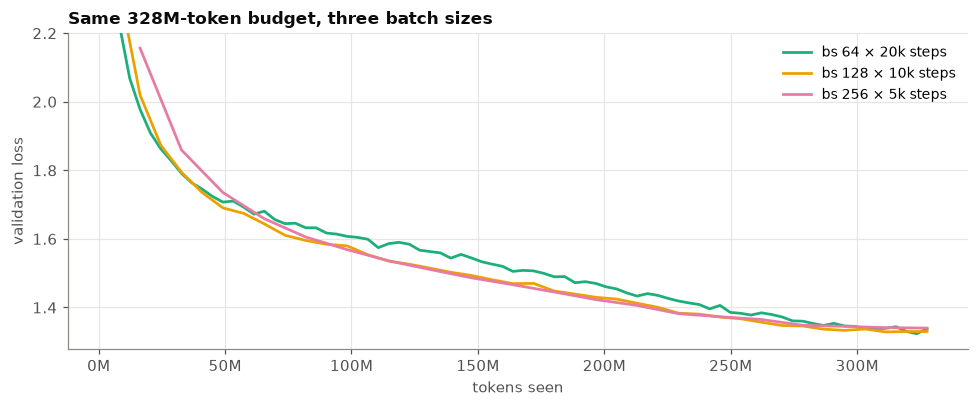

In [8]:
budget = {BS64_20K: 64, BASELINE: 128, "r3ub5u9d": 256}
fig, ax = plt.subplots(figsize=(9, 3.8))
for rid, bs in budget.items():
    r = runs[rid]
    ax.plot(r.val.index * r.tokens_per_step, r.val.values, color=BS_COLOR[bs],
            label=f"bs {bs} × {r.config['total_iters'] // 1000}k steps")
ax.set(xlabel="tokens seen", ylabel="validation loss", ylim=(1.28, 2.2), title="Same 328M-token budget, three batch sizes")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x / 1e6:.0f}M"))
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "batch_size_token_budget.png", dpi=150, bbox_inches="tight")

pd.DataFrame([
    dict(run=runs[rid].name, batch=bs, steps=runs[rid].last_step,
         tokens=f"{runs[rid].last_step * runs[rid].tokens_per_step / 1e6:.0f}M",
         final_val=round(runs[rid].val.iloc[-1], 3), min_val=round(runs[rid].val.min(), 3),
         wall_clock_min=round(runs[rid].runtime_s / 60))
    for rid, bs in budget.items()
]).style.hide(axis="index")

With the token budget fixed, all three batch sizes finish within 0.01 of each other, which is within noise. Along the way, bs 64 × 20k runs *above* the others. Its cosine schedule is twice as long, so its LR stays high for more of the run, and its loss only catches up once the schedule decays.

The wall-clock times are all close to an hour. On a single 4090 the GPU is already near saturation at bs 64, so larger batches don't buy much throughput. This is only a rough comparison, because `summer-sweep-1` ran on a different machine from the other two.

## 3. Architecture ablations

Each panel compares one change against the baseline (`summer-sweep-1`: pre-norm, RMSNorm, RoPE, SwiGLU, wd 0.1, LR 3e-3, bs 128). Everything else is held fixed.

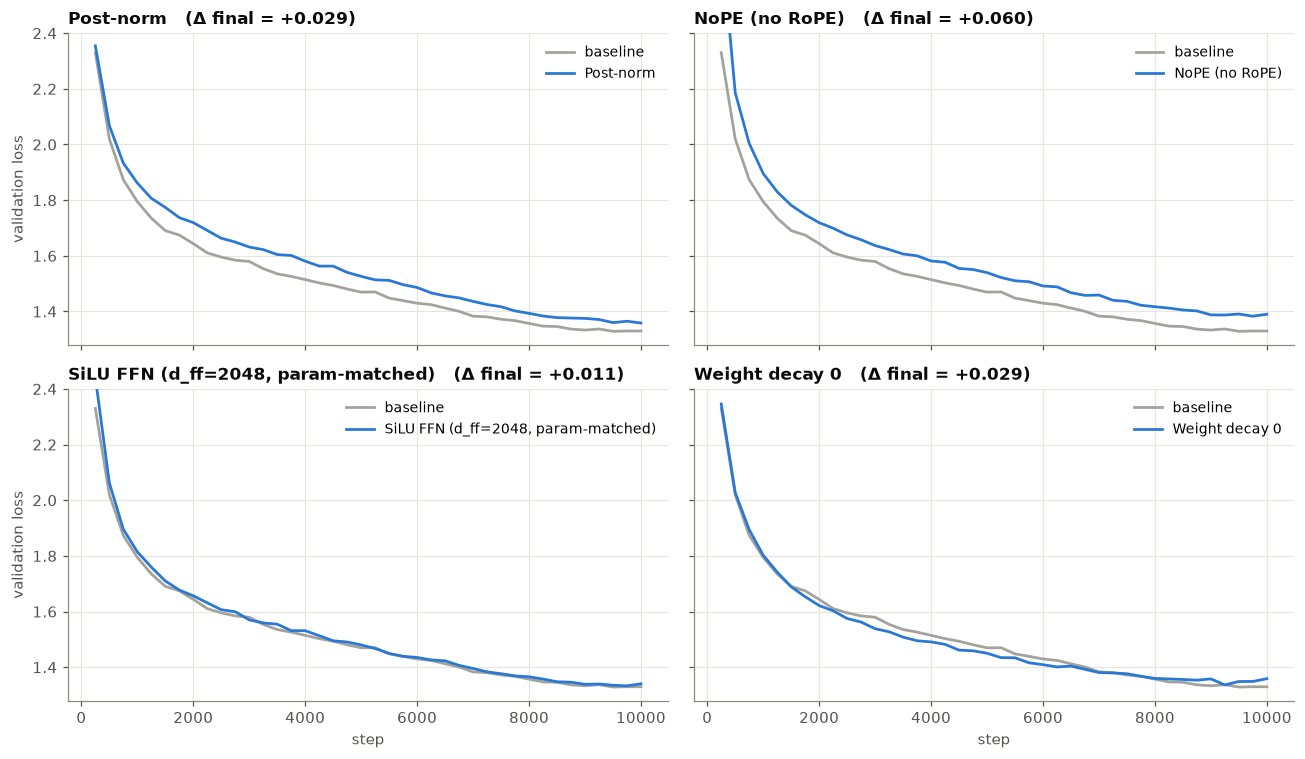

In [9]:
base = runs[BASELINE]
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, sharey=True)
for ax, (rid, label) in zip(axes.flat, ABLATIONS.items()):
    r = runs[rid]
    ax.plot(base.val.index, base.val.values, color=BASE, label="baseline")
    plot_curve(ax, r.val.index.values, r.val.values, r, ACCENT, label)
    delta = r.val.iloc[-1] - base.val.iloc[-1]
    ax.set_title(f"{label}   (Δ final = {delta:+.3f})")
    ax.legend(loc="upper right")
for ax in axes[1]:
    ax.set_xlabel("step")
for ax in axes[:, 0]:
    ax.set_ylabel("validation loss")
axes[0, 0].set_ylim(1.28, 2.4)
fig.tight_layout()
fig.savefig(FIG_DIR / "ablations.png", dpi=150, bbox_inches="tight")

**What this shows** (keep the ~0.01–0.02 noise floor in mind)

- **SiLU vs. SwiGLU**, at matched parameter count (d_ff = 4 · d_model = 2048 vs. 8/3 · d_model ≈ 1344): the difference is +0.01, which is within noise. Gating gives at most a small benefit at this scale and token budget.
- **Post-norm** trails the baseline by about 0.05 for most of training. The gap narrows to about 0.03 once the LR decays. At this depth (4 layers) and with warmup plus grad clipping, post-norm still trains fine; it is just less efficient.
- **NoPE** is about 0.06 worse and has the largest gap among these four. It is also the slowest at the very start: at step 250, its loss is 2.74 against the baseline's 2.33 (above the top of the plot). A causal decoder can still infer position from the attention mask, so it does learn, but explicit RoPE clearly helps.
- **Weight decay 0** shows the most interesting pattern. It is slightly *ahead* of the baseline from about step 2k to 6k, then falls behind and finishes about 0.03 worse. Weight decay costs a little while the LR is high and pays off during the final anneal, which matches what is usually reported for AdamW-trained LMs.

### Removing RMSNorm

This is the one ablation that fails outright, so it gets a log-scale plot of its own.

no-RMSNorm @ lr 3e-3: peak train loss 7.70e+19, final val 2.196 vs baseline 1.330
no-RMSNorm @ lr 3e-4: val at step 6250 = 1.615 vs baseline 1.567 (run was killed there)


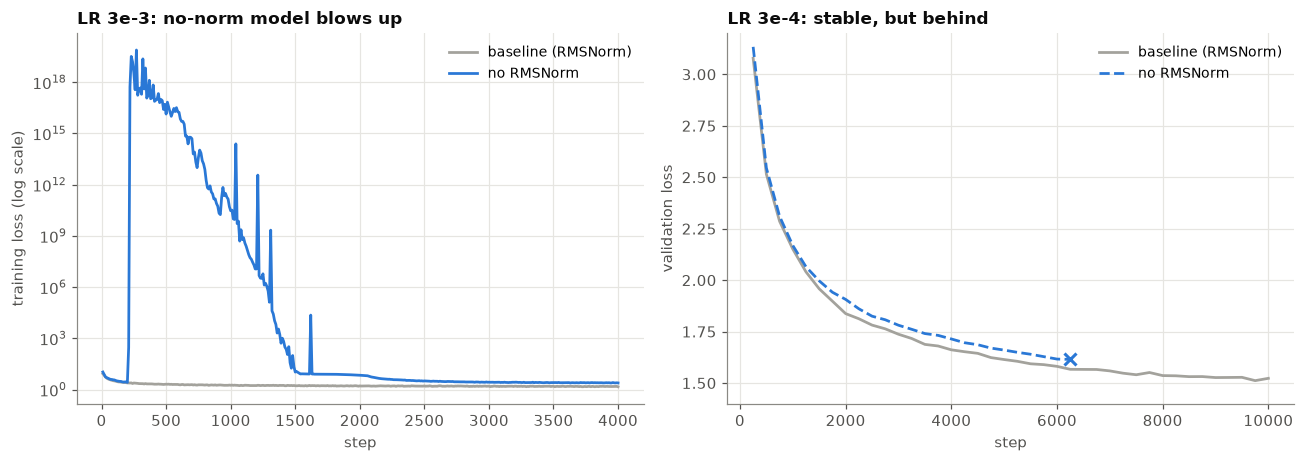

In [10]:
no_hi, no_lo, base_lo = runs[NO_NORM_HI_LR], runs[NO_NORM_LO_LR], runs[BASELINE_LO_LR]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.3))

for r, color, label in [(base, BASE, "baseline (RMSNorm)"), (no_hi, ACCENT, "no RMSNorm")]:
    t = r.train["train/loss"].loc[:4000]
    ax1.plot(t.index, t.values, color=color, label=label)
ax1.set(yscale="log", xlabel="step", ylabel="training loss (log scale)", title="LR 3e-3: no-norm model blows up")
ax1.legend()

ax2.plot(base_lo.val.index, base_lo.val.values, color=BASE, label="baseline (RMSNorm)")
plot_curve(ax2, no_lo.val.index.values, no_lo.val.values, no_lo, ACCENT, "no RMSNorm")
ax2.set(xlabel="step", ylabel="validation loss", ylim=(1.4, 3.2), title="LR 3e-4: stable, but behind")
ax2.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "no_rmsnorm.png", dpi=150, bbox_inches="tight")

print(f"no-RMSNorm @ lr 3e-3: peak train loss {no_hi.train['train/loss'].max():.2e}, "
      f"final val {no_hi.val.iloc[-1]:.3f} vs baseline {base.val.iloc[-1]:.3f}")
s = no_lo.val.index.max()
print(f"no-RMSNorm @ lr 3e-4: val at step {s} = {no_lo.val.iloc[-1]:.3f} vs baseline {base_lo.val.get(s, np.nan):.3f} "
      "(run was killed there)")

**What this shows**

- With no normalization at LR 3e-3, the run blows up **at step ~200, exactly when warmup ends** and the LR hits its peak. The training loss jumps to about 10^19, presumably because the residual stream's activations grow without bound. Gradient clipping keeps the run from producing NaNs, and it eventually recovers somewhat, but loss spikes keep recurring until about step 1.6k. It finishes at 2.20 against the baseline's 1.33.
- At a 10× smaller LR (3e-4), the no-norm model trains stably. When the run was stopped at step 6.25k, it was still 0.05 behind the baseline at the same LR, and that baseline is itself far from optimal. Normalization therefore matters in two ways: it makes high learning rates usable at all, and it helps a little even when the LR is low.

## Summary

In [11]:
rows = [("Baseline (lr 3e-3, bs 128)", BASELINE)] + [(v, k) for k, v in ABLATIONS.items()] + [
    ("No RMSNorm (lr 3e-3)", NO_NORM_HI_LR),
    ("LR 1e-2", "ug9tshkx"), ("LR 1e-3", "twk5tmaq"), ("LR 3e-4", "2g1g00vx"),
    ("bs 64 × 20k steps", BS64_20K), ("bs 256 × 5k steps", "r3ub5u9d"), ("bs 64", "owycaj86"), ("bs 16", "xm9ja9j1"), ("bs 1", "8ni155ij"),
]
summary = pd.DataFrame([
    dict(config=name, run=runs[rid].name, tokens=f"{runs[rid].last_step * runs[rid].tokens_per_step / 1e6:.0f}M",
         final_val=runs[rid].val.iloc[-1], delta_vs_baseline=runs[rid].val.iloc[-1] - base.val.iloc[-1])
    for name, rid in rows
])
summary.style.hide(axis="index").format({"final_val": "{:.3f}", "delta_vs_baseline": "{:+.3f}"})

config,run,tokens,final_val,delta_vs_baseline
"Baseline (lr 3e-3, bs 128)",summer-sweep-1,328M,1.330,+0.000
Post-norm,devoted-lion-20,328M,1.359,+0.029
NoPE (no RoPE),confused-surf-21,328M,1.390,+0.060
"SiLU FFN (d_ff=2048, param-matched)",quiet-oath-22,328M,1.340,+0.011
Weight decay 0,fanciful-energy-18,328M,1.359,+0.029
No RMSNorm (lr 3e-3),stilted-sponge-19,328M,2.196,+0.866
LR 1e-2,absurd-totem-3,328M,1.330,+0.000
LR 1e-3,different-wood-13,328M,1.381,+0.051
LR 3e-4,leafy-cloud-4,328M,1.523,+0.193
bs 64 × 20k steps,upbeat-eon-15,328M,1.338,+0.008


## Sample generation

*None of the wandb runs logged generated text. The training script logs only `train/loss`, `lr`, and `val/loss`, so samples have to be produced from a checkpoint.*

The best run is **`summer-sweep-1`** (LR 3e-3, bs 128, val loss 1.330), and its final checkpoint is `summer-sweep-1_iter10000`. `absurd-totem-3` (LR 1e-2) and `upbeat-eon-15` (bs 64 × 20k) are statistically tied with it.

TODO: add generated sample here.